In [1]:
# importing important libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,PowerTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import plot_tree, DecisionTreeClassifier
from xgboost import XGBClassifier

In [2]:
# reading the dataset via pandas library

df = pd.read_csv('training.csv')

In [3]:
df.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [4]:
df.shape

(45528, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  object 
 1   name                     45528 non-null  object 
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  object 
 4   owns_car                 44981 non-null  object 
 5   owns_house               45528 non-null  object 
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  object 
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)  

In [6]:
 # dropping first two columns because they are useless

df.drop(df.columns[[0,1]], axis = 1, inplace = True)

In [7]:
df.head()

,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [8]:
df.shape

(45528, 17)

In [9]:
# checking if there is any duplicate rows in our data or not.

df.duplicated().sum()

np.int64(0)

So, no duplicate rows in our dataset. Lucky !!!

In [10]:
# separating all categorical and numerical columns

category_col = []
numerical_col = []
for i in df.columns:
    if(df[i].dtype == 'object'):
        category_col.append(i)
    else:
        numerical_col.append(i)

In [11]:
#printing categorical columns
category_col

['gender', 'owns_car', 'owns_house', 'occupation_type']

In [12]:
# printing numerical columns
numerical_col

['age',
 'no_of_children',
 'net_yearly_income',
 'no_of_days_employed',
 'total_family_members',
 'migrant_worker',
 'yearly_debt_payments',
 'credit_limit',
 'credit_limit_used(%)',
 'credit_score',
 'prev_defaults',
 'default_in_last_6months',
 'credit_card_default']

In [13]:
# distribution of output
df['credit_card_default'].value_counts(normalize = True)

credit_card_default
0    0.918797
1    0.081203
Name: proportion, dtype: float64

In [14]:
# check the missing values of categorical columns
df[category_col].isnull().sum()

gender               0
owns_car           547
owns_house           0
occupation_type      0
dtype: int64

In [15]:
df['owns_car'].fillna(df['owns_car'].mode()[0], inplace = True)

/var/folders/49/dlfryms541x6nvjcz5yz0hh80000gn/T/ipykernel_37254/1222758722.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['owns_car'].fillna(df['owns_car'].mode()[0], inplace = True)


In [16]:
df['owns_car'].isnull().sum()

np.int64(0)

In [17]:
# again check the missing values of categorical columns
df[category_col].isnull().sum()

gender             0
owns_car           0
owns_house         0
occupation_type    0
dtype: int64

In [18]:
# check the missing values of numerical columns
df[numerical_col].isnull().sum()

age                          0
no_of_children             774
net_yearly_income            0
no_of_days_employed        463
total_family_members        83
migrant_worker              87
yearly_debt_payments        95
credit_limit                 0
credit_limit_used(%)         0
credit_score                 8
prev_defaults                0
default_in_last_6months      0
credit_card_default          0
dtype: int64

In [19]:
# dropiing all rows of a few column where data value is Nan

df.dropna(subset=['yearly_debt_payments', 'migrant_worker', 'total_family_members', 'credit_score'], inplace = True)

In [20]:
df[numerical_col].isnull().sum()

age                          0
no_of_children             771
net_yearly_income            0
no_of_days_employed        461
total_family_members         0
migrant_worker               0
yearly_debt_payments         0
credit_limit                 0
credit_limit_used(%)         0
credit_score                 0
prev_defaults                0
default_in_last_6months      0
credit_card_default          0
dtype: int64

In [21]:
df['no_of_days_employed']

0          612.0
1         2771.0
2          204.0
3        11941.0
4         1459.0
          ...   
45523      117.0
45524      966.0
45525     1420.0
45526     2457.0
45527     1210.0
Name: no_of_days_employed, Length: 45256, dtype: float64

In [22]:
df.fillna(df[['no_of_children', 'no_of_days_employed']].mean(), inplace = True)

In [23]:
df[numerical_col].isnull().sum()

age                        0
no_of_children             0
net_yearly_income          0
no_of_days_employed        0
total_family_members       0
migrant_worker             0
yearly_debt_payments       0
credit_limit               0
credit_limit_used(%)       0
credit_score               0
prev_defaults              0
default_in_last_6months    0
credit_card_default        0
dtype: int64

All null values are gone now and filled with mean values

In [24]:
df['gender'].value_counts()

gender
F      29779
M      15476
XNA        1
Name: count, dtype: int64

In [25]:
df.shape

(45256, 17)

In [26]:
label = LabelEncoder()
df['owns_car'] = label.fit_transform(df['owns_car'])

label2 = LabelEncoder()
df['owns_house'] = label2.fit_transform(df['owns_house'])

label3 = LabelEncoder()
df['gender'] = label3.fit_transform(df['gender'])

In [27]:
df

,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,46,0,0,1,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,29,1,0,1,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,37,1,0,1,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,39,0,0,1,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,46,1,1,1,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,55,0,0,0,2.0,96207.57,117.0,Unknown,4.0,0.0,11229.54,29663.83,82,907.0,0,0,0
45524,31,0,0,1,0.0,383476.74,966.0,Accountants,2.0,1.0,43369.91,139947.16,32,679.0,0,0,0
45525,27,0,0,1,0.0,260052.18,1420.0,Core staff,2.0,0.0,22707.51,83961.83,46,727.0,0,0,0
45526,32,1,1,0,0.0,157363.04,2457.0,Laborers,2.0,0.0,20150.10,25538.72,92,805.0,0,0,0


In [28]:
df['occupation_type'].value_counts()

occupation_type
Unknown                  14207
Laborers                  8085
Sales staff               4683
Core staff                4046
Managers                  3152
Drivers                   2733
High skill tech staff     1667
Accountants               1468
Medicine staff            1268
Security staff            1023
Cooking staff              897
Cleaning staff             663
Private service staff      387
Low-skill Laborers         335
Waiters/barmen staff       202
Secretaries                197
Realty agents              100
HR staff                    78
IT staff                    65
Name: count, dtype: int64

In [29]:
encoder = OrdinalEncoder(categories = 'auto')

df['occupation_type'] = encoder.fit_transform(df[['occupation_type']])

In [30]:
df

,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,46,0,0,1,0.0,107934.04,612.0,17.0,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,29,1,0,1,0.0,109862.62,2771.0,8.0,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,37,1,0,1,0.0,230153.17,204.0,8.0,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,39,0,0,1,0.0,122325.82,11941.0,3.0,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,46,1,1,1,0.0,387286.00,1459.0,3.0,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,55,0,0,0,2.0,96207.57,117.0,17.0,4.0,0.0,11229.54,29663.83,82,907.0,0,0,0
45524,31,0,0,1,0.0,383476.74,966.0,0.0,2.0,1.0,43369.91,139947.16,32,679.0,0,0,0
45525,27,0,0,1,0.0,260052.18,1420.0,3.0,2.0,0.0,22707.51,83961.83,46,727.0,0,0,0
45526,32,1,1,0,0.0,157363.04,2457.0,8.0,2.0,0.0,20150.10,25538.72,92,805.0,0,0,0


In [31]:
# calculating the cross correlation of each columns with all other columns
df.corr()

,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
age,1.000000,-0.004486,-0.006984,0.002446,-0.008695,0.004091,0.000238,-0.002193,-0.010465,-0.005491,-0.002453,0.004466,-0.005664,0.001327,0.000688,-0.001627,-0.001425
gender,-0.004486,1.000000,0.342587,-0.041803,0.054929,0.028034,-0.154218,-0.129323,0.088653,0.134759,0.081257,0.026929,0.019240,-0.032324,0.049692,0.045513,0.057311
owns_car,-0.006984,0.342587,1.000000,0.005702,0.103950,0.031728,-0.150427,-0.116746,0.150186,0.093667,0.133617,0.030405,-0.002455,0.008278,-0.011435,-0.015772,-0.016993
owns_house,0.002446,-0.041803,0.005702,1.000000,-0.004995,0.003037,0.061095,0.035285,0.003336,-0.025573,-0.003404,0.003231,0.001153,0.002165,0.002928,-0.002597,-0.003010
no_of_children,-0.008695,0.054929,0.103950,-0.004995,1.000000,0.008825,-0.239823,-0.145438,0.872659,0.069349,0.028685,0.009236,0.007370,-0.015068,0.019564,0.021586,0.023448
net_yearly_income,0.004091,0.028034,0.031728,0.003037,0.008825,1.000000,-0.029237,-0.018673,0.010404,0.001313,0.076899,0.993403,0.002694,-0.009734,-0.004753,0.015080,0.011482
no_of_days_employed,0.000238,-0.154218,-0.150427,0.061095,-0.239823,-0.029237,1.000000,0.519955,-0.228339,-0.218425,-0.104109,-0.027600,-0.018488,0.035578,-0.036135,-0.034293,-0.047088
occupation_type,-0.002193,-0.129323,-0.116746,0.035285,-0.145438,-0.018673,0.519955,1.000000,-0.144974,-0.111138,-0.074215,-0.018327,-0.005169,0.016491,-0.011768,-0.011677,-0.021094
total_family_members,-0.010465,0.088653,0.150186,0.003336,0.872659,0.010404,-0.228339,-0.144974,1.000000,0.080066,0.078793,0.010201,0.001720,-0.011603,0.010516,0.013415,0.010493
migrant_worker,-0.005491,0.134759,0.093667,-0.025573,0.069349,0.001313,-0.218425,-0.111138,0.080066,1.000000,0.013828,-0.000296,0.009628,-0.012970,0.028747,0.030010,0.033952


<Axes: >

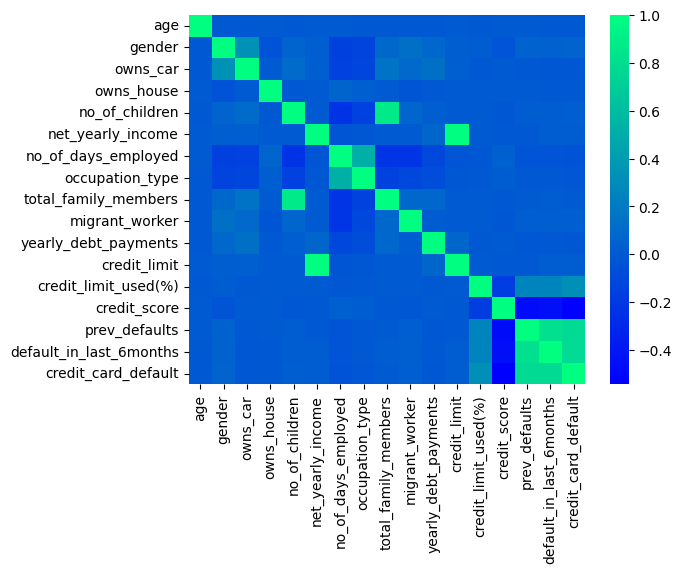

In [32]:
# visualizing the cross correlation of each individual column with all other coulmns
sns.heatmap(df.corr(), cmap = 'winter')

We see the no_of_child is also again counted in no_of _family member. So we can drop the column no of_child, bacause no of total family member counts all.

In [33]:
df.drop(columns = ['no_of_children'], inplace = True)

In [34]:
df.drop(columns = ['default_in_last_6months'], inplace = True)

<Axes: >

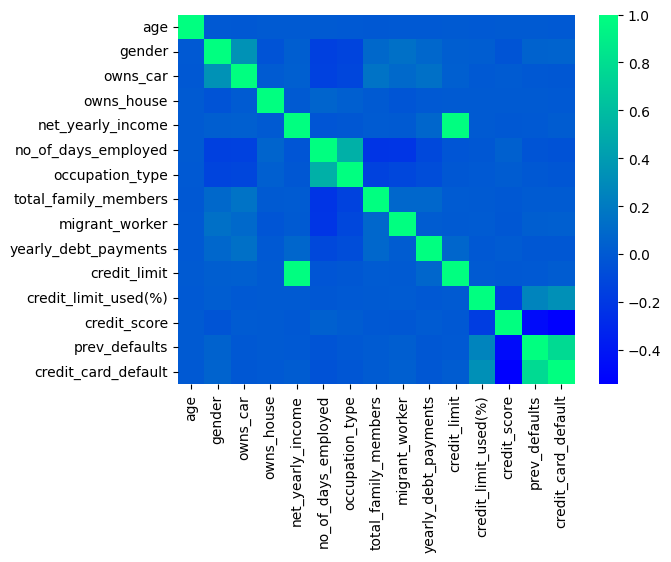

In [35]:
# final cross correlation heatmap

sns.heatmap(df.corr(), cmap = 'winter')

In [36]:
num_col = df[['age','net_yearly_income','no_of_days_employed','total_family_members',
 'yearly_debt_payments','credit_limit','credit_limit_used(%)','credit_score']]

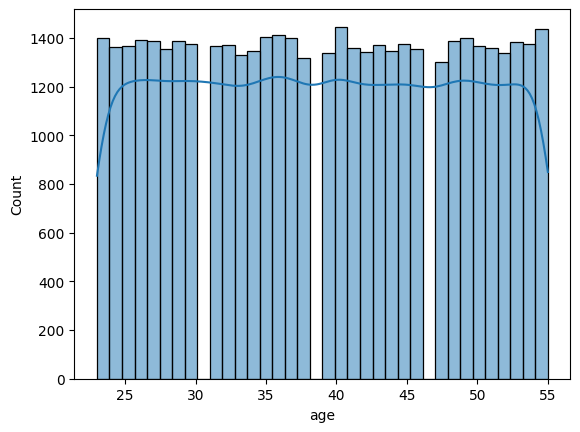

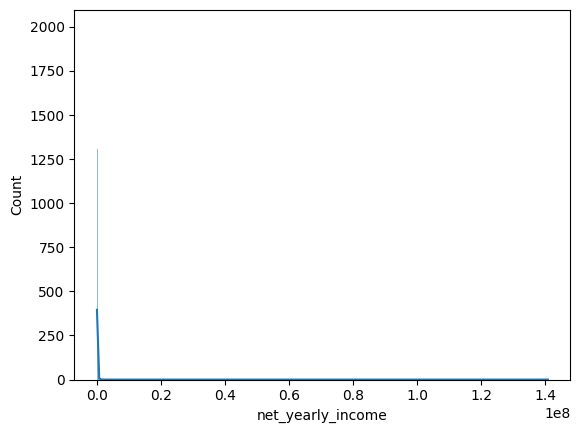

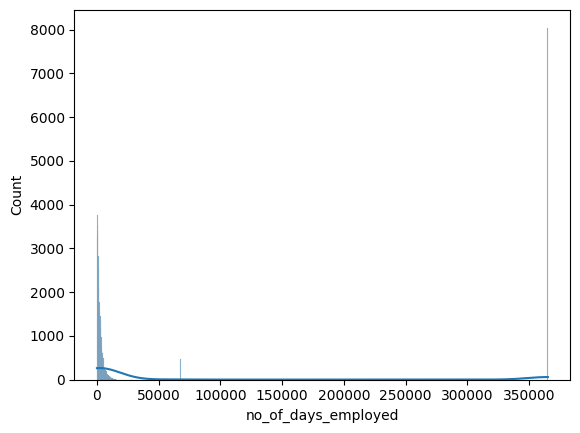

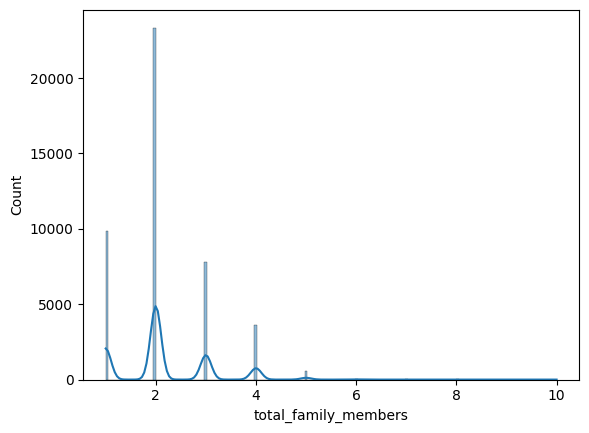

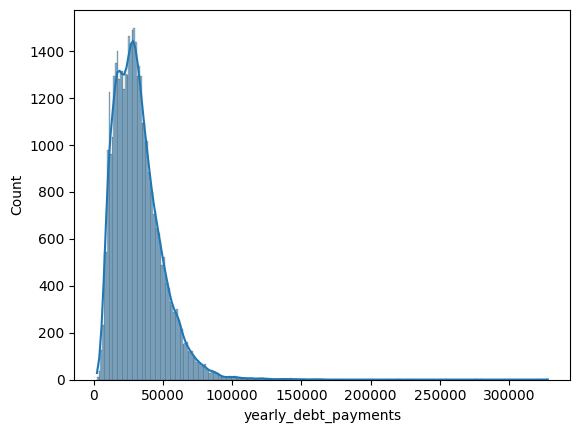

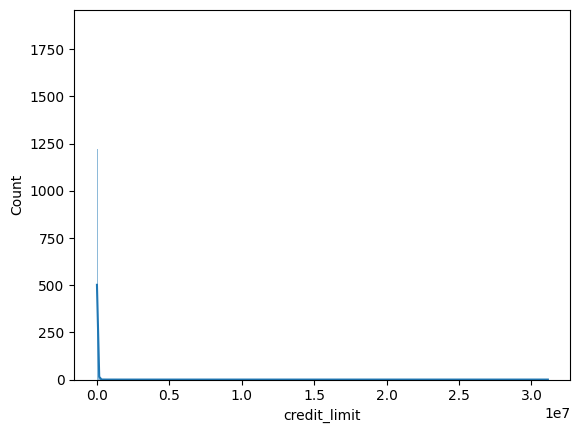

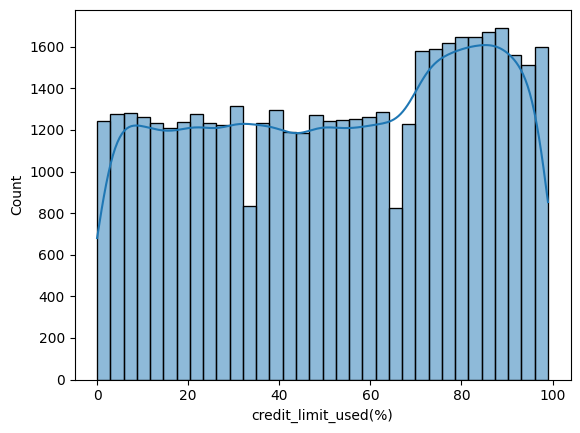

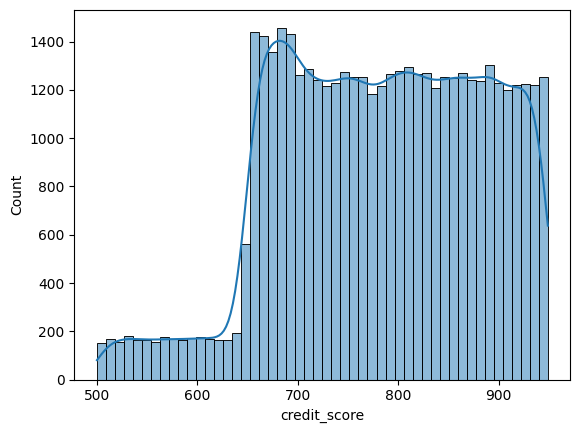

In [37]:
for col in num_col:
    sns.histplot(df[col], kde = True)
    plt.show()

In [38]:
# using log transformation on yearly debt payments
df['yearly_debt_payments'] = np.log(df['yearly_debt_payments'])

# using log transformation on net yearly income
df['net_yearly_income'] = (np.log(df['net_yearly_income']))

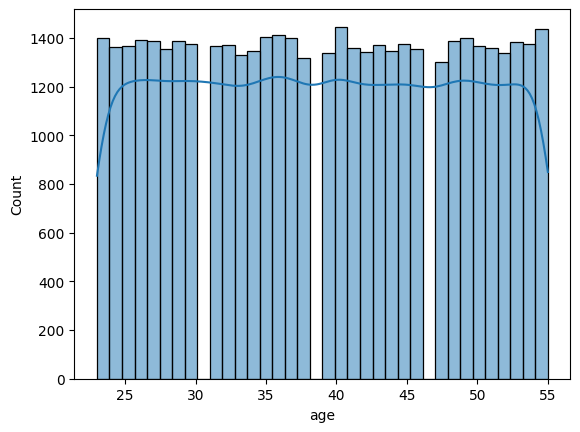

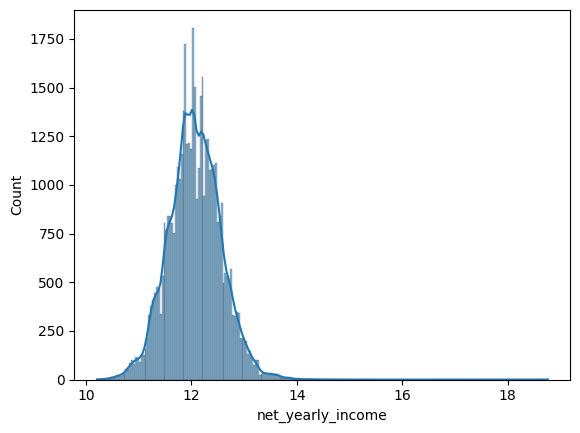

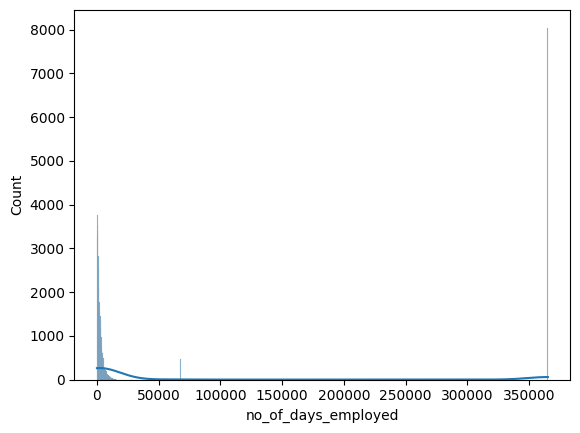

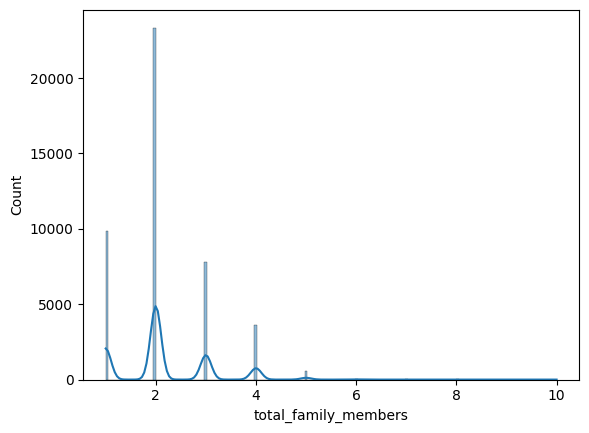

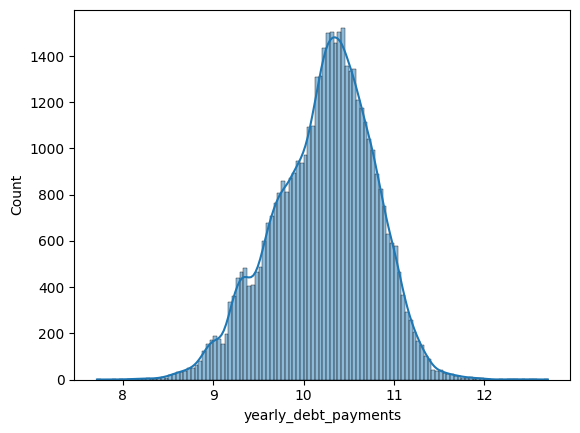

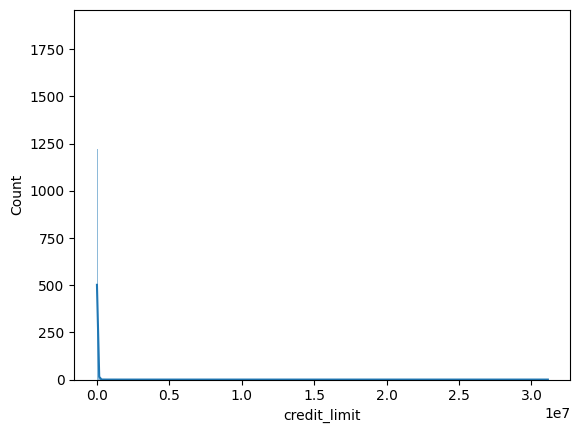

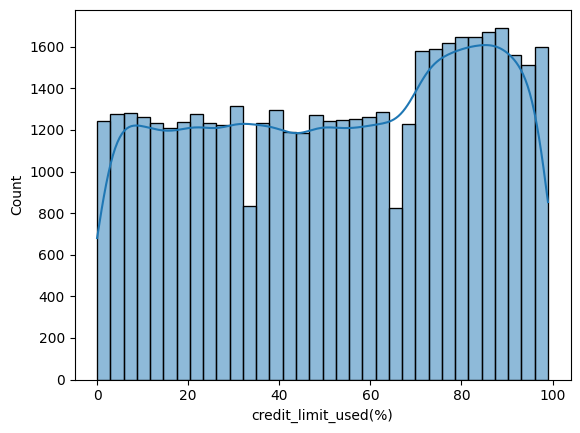

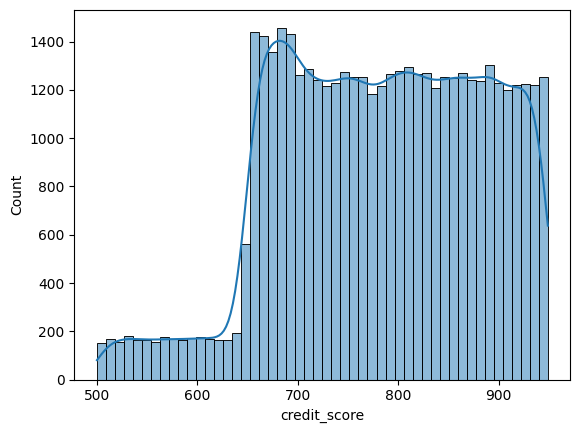

In [39]:
for col in num_col:
    sns.histplot(df[col], kde = True)
    plt.show()

In [40]:
df

,age,gender,owns_car,owns_house,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,credit_card_default
0,46,0,0,1,11.589276,612.0,17.0,1.0,1.0,10.406390,18690.93,73,544.0,2,1
1,29,1,0,1,11.606986,2771.0,8.0,2.0,0.0,9.637536,37745.19,52,857.0,0,0
2,37,1,0,1,12.346500,204.0,8.0,2.0,0.0,10.787598,41598.36,43,650.0,0,0
3,39,0,0,1,11.714443,11941.0,3.0,2.0,0.0,10.024570,32627.76,20,754.0,0,0
4,46,1,1,1,12.866919,1459.0,3.0,1.0,0.0,10.552760,52950.64,75,927.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,55,0,0,0,11.474263,117.0,17.0,4.0,0.0,9.326303,29663.83,82,907.0,0,0
45524,31,0,0,1,12.857034,966.0,0.0,2.0,1.0,10.677521,139947.16,32,679.0,0,0
45525,27,0,0,1,12.468638,1420.0,3.0,2.0,0.0,10.030451,83961.83,46,727.0,0,0
45526,32,1,1,0,11.966311,2457.0,8.0,2.0,0.0,9.910965,25538.72,92,805.0,0,0


In [41]:
scaler3 = MinMaxScaler()
col = ['age', 'credit_score']
df[col] = scaler3.fit_transform(df[col])

In [42]:
df

,age,gender,owns_car,owns_house,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,credit_card_default
0,0.71875,0,0,1,11.589276,612.0,17.0,1.0,1.0,10.406390,18690.93,73,0.097996,2,1
1,0.18750,1,0,1,11.606986,2771.0,8.0,2.0,0.0,9.637536,37745.19,52,0.795100,0,0
2,0.43750,1,0,1,12.346500,204.0,8.0,2.0,0.0,10.787598,41598.36,43,0.334076,0,0
3,0.50000,0,0,1,11.714443,11941.0,3.0,2.0,0.0,10.024570,32627.76,20,0.565702,0,0
4,0.71875,1,1,1,12.866919,1459.0,3.0,1.0,0.0,10.552760,52950.64,75,0.951002,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,1.00000,0,0,0,11.474263,117.0,17.0,4.0,0.0,9.326303,29663.83,82,0.906459,0,0
45524,0.25000,0,0,1,12.857034,966.0,0.0,2.0,1.0,10.677521,139947.16,32,0.398664,0,0
45525,0.12500,0,0,1,12.468638,1420.0,3.0,2.0,0.0,10.030451,83961.83,46,0.505568,0,0
45526,0.28125,1,1,0,11.966311,2457.0,8.0,2.0,0.0,9.910965,25538.72,92,0.679287,0,0


In [43]:
scaler4 = StandardScaler()
col = ['net_yearly_income', 'no_of_days_employed', 'yearly_debt_payments', 'credit_limit']
df[col] = scaler4.fit_transform(df[col])

In [44]:
df

,age,gender,owns_car,owns_house,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,credit_card_default
0,0.71875,0,0,1,-0.964236,-0.483227,17.0,1.0,1.0,0.329999,-0.166711,73,0.097996,2,1
1,0.18750,1,0,1,-0.928521,-0.467648,8.0,2.0,0.0,-1.065661,-0.039016,52,0.795100,0,0
2,0.43750,1,0,1,0.562789,-0.486171,8.0,2.0,0.0,1.021986,-0.013193,43,0.334076,0,0
3,0.50000,0,0,1,-0.711822,-0.401480,3.0,2.0,0.0,-0.363099,-0.073311,20,0.565702,0,0
4,0.71875,1,1,1,1.612268,-0.477115,3.0,1.0,0.0,0.595696,0.062885,75,0.951002,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,1.00000,0,0,0,-1.196170,-0.486798,17.0,4.0,0.0,-1.630627,-0.093174,82,0.906459,0,0
45524,0.25000,0,0,1,1.592335,-0.480672,0.0,2.0,1.0,0.822169,0.645905,32,0.398664,0,0
45525,0.12500,0,0,1,0.809091,-0.477396,3.0,2.0,0.0,-0.352424,0.270711,46,0.505568,0,0
45526,0.28125,1,1,0,-0.203904,-0.469914,8.0,2.0,0.0,-0.569321,-0.120819,92,0.679287,0,0


In [45]:
# finding the boundaries of distribution

high_credit = df['credit_limit'].mean()+2*df['credit_limit'].std()
low_credit = df['credit_limit'].mean()-2*df['credit_limit'].std()

print('highest allowed credit limit = ', high_credit)
print('lowest allowed credit limit = ', low_credit)

highest allowed credit limit =  2.0000220968837876
lowest allowed credit limit =  -2.0000220968837876


In [46]:
# finding out the outlier in credit limit column
df[(df['credit_limit'] > high_credit) | (df['credit_limit'] < low_credit)].shape

(24, 15)

In [47]:
# defining the new dataset without outlier in credit limit

df = df[(df['credit_limit'] < high_credit) & (df['credit_limit'] > low_credit)]

In [48]:
df.shape

(45232, 15)

In [49]:
# find the boundaries of distrtibution of net yearly income

high_income = df['net_yearly_income'].mean() + 3*df['net_yearly_income'].std()
low_income = df['net_yearly_income'].mean() - 3*df['net_yearly_income'].std()

print('highest allowed income = ', high_income)
print('lowest allowed income = ', low_income)

highest allowed income =  2.975650581174583
lowest allowed income =  -2.980875163578851


In [50]:
df[(df['net_yearly_income'] > high_income) | (df['net_yearly_income'] < low_income)]

,age,gender,owns_car,owns_house,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,credit_card_default
335,0.43750,1,1,1,3.266392,-0.471198,10.0,1.0,0.0,1.180665,1.012289,74,0.006682,1,1
595,0.18750,1,0,0,3.096995,-0.471516,10.0,2.0,0.0,4.184900,1.175925,65,0.759465,0,0
709,0.75000,0,0,0,3.144119,-0.484893,0.0,2.0,0.0,2.057851,1.576719,43,0.988864,0,0
932,0.78125,1,0,0,3.176590,-0.462417,0.0,2.0,0.0,0.839871,0.382106,7,0.587973,0,0
1053,0.71875,0,0,1,3.239659,-0.482354,10.0,2.0,0.0,0.681843,0.912801,84,0.761693,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45158,0.31250,1,1,0,3.492719,-0.469690,17.0,4.0,1.0,1.756664,1.822141,29,0.643653,0,0
45296,0.59375,0,0,1,3.130821,-0.485348,6.0,4.0,0.0,2.295547,1.608240,38,0.438753,0,0
45365,0.28125,0,1,0,3.236756,-0.435733,10.0,2.0,0.0,1.493439,0.976847,11,0.674833,0,0
45386,0.31250,1,1,1,3.450576,-0.457625,10.0,2.0,1.0,1.230312,1.440163,83,0.612472,0,0


In [51]:
df = df[(df['net_yearly_income'] < high_income) & (df['net_yearly_income'] > low_income)]

In [52]:
# find the boundaries of distrtibution of number of dayes employed

high_days = df['no_of_days_employed'].mean() + 3*df['no_of_days_employed'].std()
low_days = df['no_of_days_employed'].mean() - 3*df['no_of_days_employed'].std()

print('highest allowed income = ', high_days)
print('lowest allowed income = ', low_days)

highest allowed income =  2.998700476032767
lowest allowed income =  -2.999488876020186


In [53]:
df[(df['no_of_days_employed'] > high_days) | (df['no_of_days_employed'] < low_days)].shape

(0, 15)

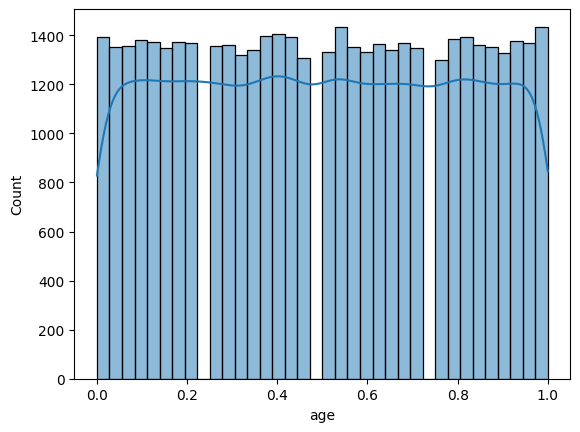

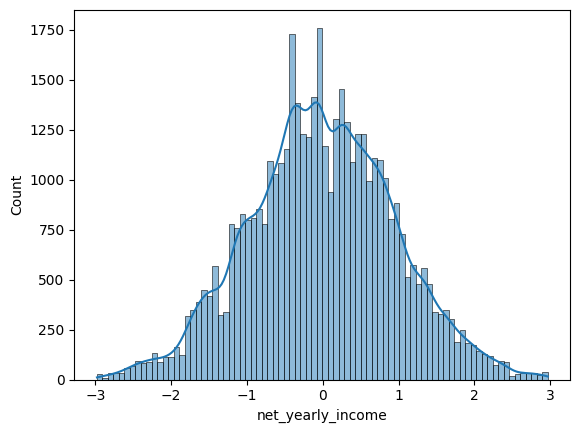

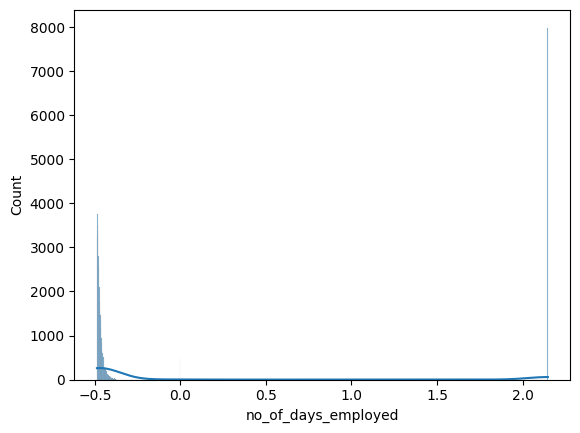

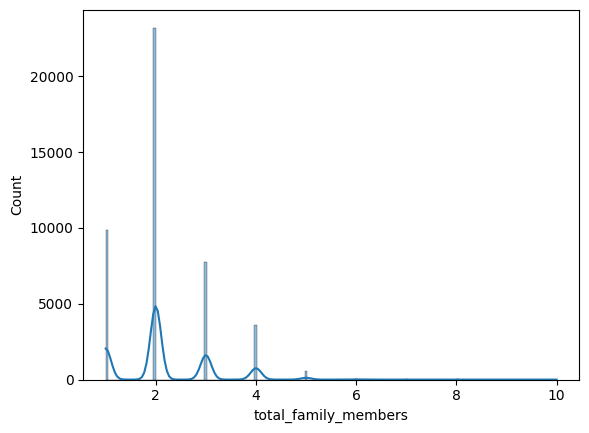

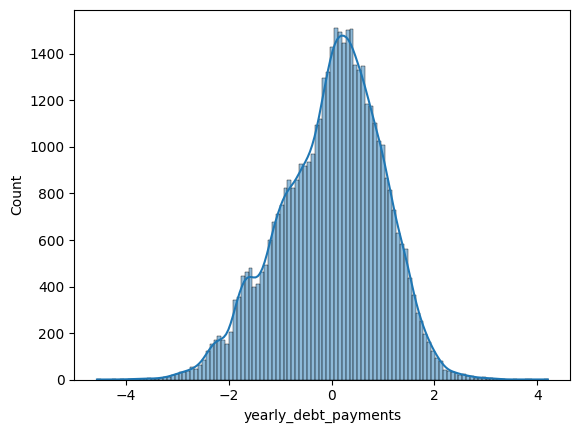

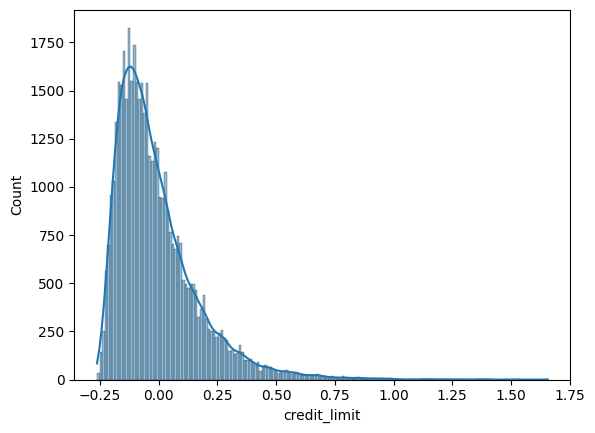

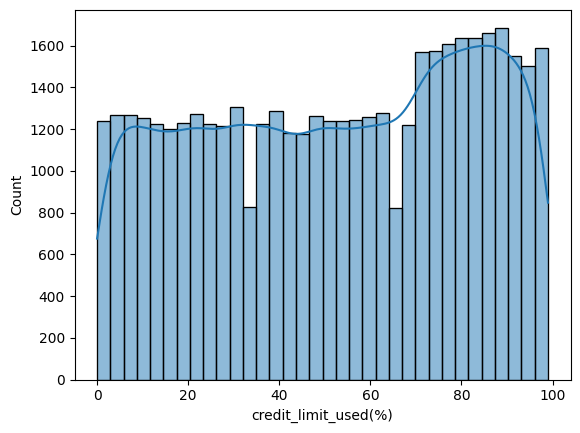

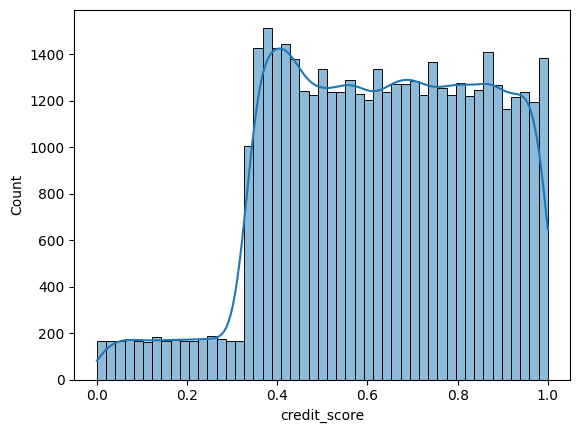

In [54]:
for col in num_col:
    sns.histplot(df[col], kde = True)
    plt.show()

In [55]:
# Dividing the data into input and output part
x = df.iloc[:, :-1] # Input 
y = df.iloc[:,-1]  # Output

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [57]:
x_train.shape

(35991, 14)

In [58]:
y_train

1570     1
34587    0
40149    0
20679    0
35957    0
        ..
11416    0
45265    1
38625    0
869      0
15988    1
Name: credit_card_default, Length: 35991, dtype: int64

# Logistic Regression

In [59]:
# calculating using logiostic regression
lr = LogisticRegression()
lr.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [60]:
y_pred = lr.predict(x_test)

In [61]:
# confusion matrix
confusion_matrix(y_test, y_pred)

array([[8245,   15],
       [ 164,  574]])

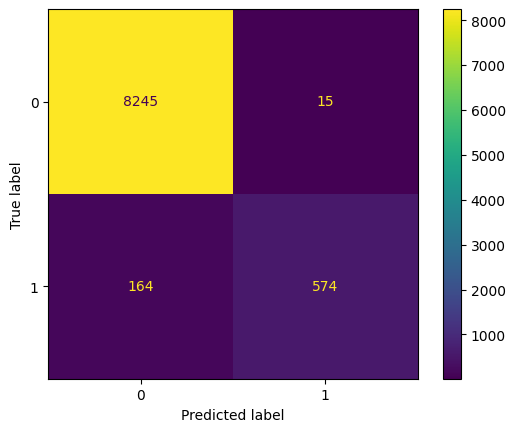

In [62]:
# creating the confusion matrix and displaying the confusion matrix 

display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels = [0,1])
display.plot()
plt.show()

In [63]:
accuracy_score(y_test, y_pred)

0.980106690375639

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8260
           1       0.97      0.78      0.87       738

    accuracy                           0.98      8998
   macro avg       0.98      0.89      0.93      8998
weighted avg       0.98      0.98      0.98      8998



# Random Forest 

In [65]:
# Applying the random forets classifier

rfc = RandomForestClassifier(random_state = 42, oob_score = True)

rfc.fit(x_train, y_train)

y_pred2 = rfc.predict(x_test)

In [66]:
confusion_matrix(y_test, y_pred2)

array([[8252,    8],
       [ 163,  575]])

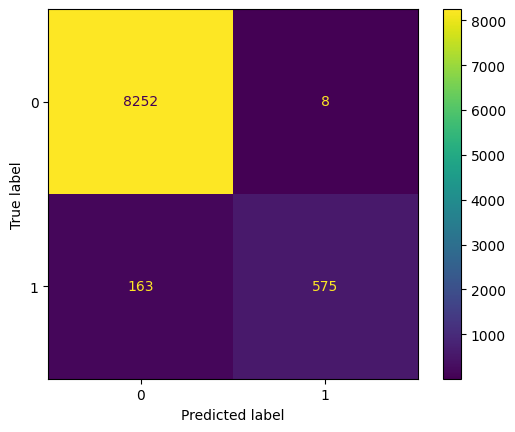

In [67]:
# plotting the confusion matrix for random forest

display2 = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred2), display_labels = [0,1])
display2.plot()
plt.show()

In [68]:
# classification re1port of random forest

print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8260
           1       0.99      0.78      0.87       738

    accuracy                           0.98      8998
   macro avg       0.98      0.89      0.93      8998
weighted avg       0.98      0.98      0.98      8998



In [69]:
# accuracy score of random forest

accuracy_score(y_test, y_pred2)

0.9809957768392976

# Decision Tree

In [70]:
# Applyiong decision tree classifier on the dataset

dtc = DecisionTreeClassifier()

dtc.fit(x_train, y_train)

DecisionTreeClassifier()

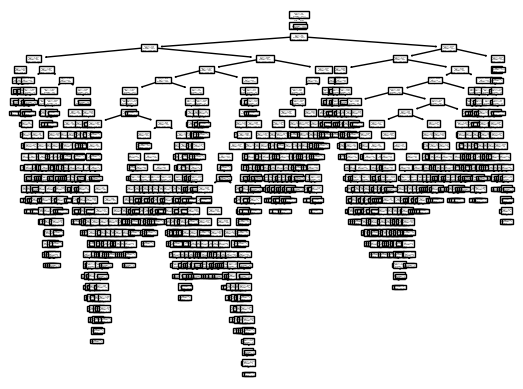

In [71]:
# plotting the decision tree

plot_tree(rfc.estimators_[0])
plt.show()

In [72]:
y_pred3 = dtc.predict(x_test)

In [73]:
confusion_matrix(y_test, y_pred3)

array([[8137,  123],
       [ 118,  620]])

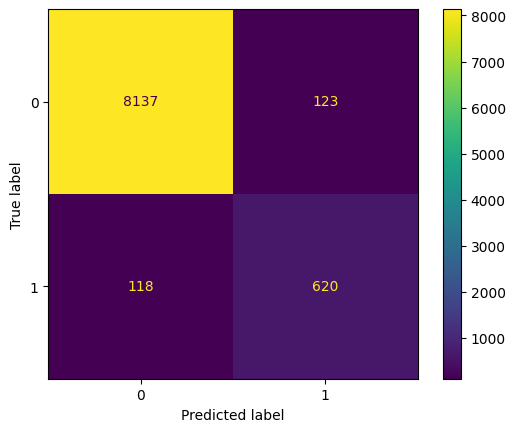

In [74]:
display3 = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred3), display_labels=[0, 1])
display3.plot()
plt.show()

In [75]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8260
           1       0.83      0.84      0.84       738

    accuracy                           0.97      8998
   macro avg       0.91      0.91      0.91      8998
weighted avg       0.97      0.97      0.97      8998



In [76]:
accuracy_score(y_test, y_pred3)

0.973216270282285

# Gradient Boost

In [77]:
# Applying gradient boost on the dataset

gbc = GradientBoostingClassifier()

gbc.fit(x_train, y_train)

GradientBoostingClassifier()

In [78]:
y_pred4 = gbc.predict(x_test)

In [79]:
confusion_matrix(y_test, y_pred4)

array([[8258,    2],
       [ 167,  571]])

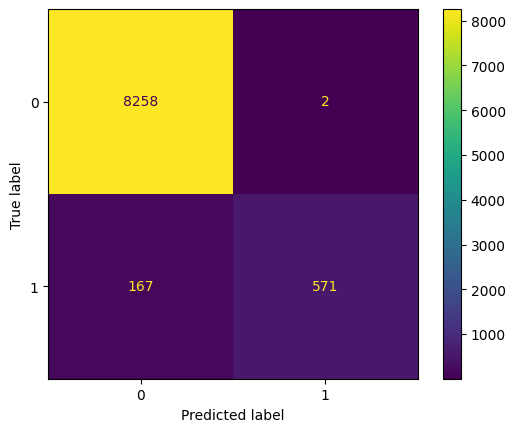

In [80]:
display4 = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred4), display_labels=[0,1])
display4.plot()
plt.show()

In [81]:
print(classification_report(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8260
           1       1.00      0.77      0.87       738

    accuracy                           0.98      8998
   macro avg       0.99      0.89      0.93      8998
weighted avg       0.98      0.98      0.98      8998



In [82]:
# Accyracy score of Gradient Boost
accuracy_score(y_test, y_pred4)

0.9812180484552123

# XGBoost (Extreme Gradient Boost)

In [83]:
# Creating the XGBoost model

model = XGBClassifier(n_estimators = 400, learning_rate = 0.01, 
                      eval_metric = 'logloss')

model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [84]:
y_pred5 = model.predict(x_test)

In [85]:
accuracy_score(y_test, y_pred5)

0.9812180484552123

# Apply GridSearchCV on XGBoost

In [93]:
parameters = {
    'n_estimators' : [500, 600, 700, 800, 900],
    'colsample_bytree' : [0.6,0.7,0.8,0.9,1],
    'learning_rate' : [0.005,0.01,0.02],
    'max_depth' : [10,20,40,50,None],
    'subsample' : [0.5,0.8,1.0]
}
print(parameters)

{'n_estimators': [500, 600, 700, 800, 900], 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1], 'learning_rate': [0.005, 0.01, 0.02], 'max_depth': [10, 20, 40, 50, None], 'subsample': [0.5, 0.8, 1.0]}


In [94]:
xg = XGBClassifier()

xg_grid = GridSearchCV(estimator = xg,
                         param_grid = parameters,
                         cv = 5,
                         verbose = 2,
                         n_jobs = -1
                        ) 

In [95]:
xg_grid.fit(x_train, y_train)

Fitting 5 folds for each of 1125 candidates, totalling 5625 fits
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=500, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=500, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=600, subsample=0.5; total time=   1.7s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=600, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=700, subsample=0.8; total time=   2.0s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=700, subsample=1.0; total time=   1.8s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=800, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=0.6, learning_rate=0.005, max_depth=10, n_estimators=800, subsample=1.0; total time

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1],
                         'learning_rate': [0.005, 0.01, 0.02],
                         'max_depth': [10, 20, 40, 50, None],
                         'n_estimators': [500, 600, 700, 800, 900],
                         'subsample': [0.5, 0.8, 1.0]},
             verbose=2)

In [96]:
xg_grid.best_params_

{'colsample_bytree': 0.6,
 'learning_rate': 0.005,
 'max_depth': 40,
 'n_estimators': 900,
 'subsample': 0.8}

In [97]:
xg_grid.best_score_

np.float64(0.9806062525818531)

[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=600, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=700, subsample=0.5; total time=   3.5s
[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=700, subsample=0.8; total time=   3.0s
[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=800, subsample=0.5; total time=   4.0s
[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=800, subsample=0.8; total time=   3.8s
[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=900, subsample=0.5; total time=   5.3s
[CV] END colsample_bytree=0.9, learning_rate=0.02, max_depth=None, n_estimators=900, subsample=1.0; total time=   4.0s
[CV] END colsample_bytree=1, learning_rate=0.005, max_depth=10, n_estimators=500, subsample=0.5; total time=   3.2s
[CV] END colsample_bytree=1, learning_rate=0.005, m